# Задание 2. Методы линейной регрессии и их сравнение

#### 1. Загрузка датасета и вывод на экран

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from threadpoolctl import threadpool_limits

pd.set_option('display.float_format', '{:,.6f}'.format)
pd.set_option('display.max_columns', 12)
plt.rcParams.update({'figure.figsize': (9, 4.5), 'figure.dpi': 110})

data = pd.read_csv('auto_dataset.csv')
display(data.head())
print(f'Размер датасета: {data.shape}')
print(f'Пропуски: {data.isna().sum().sum()}')
print(f'Полные дубликаты: {data.duplicated().sum()}')


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


Размер датасета: (1000, 10)
Пропуски: 0
Полные дубликаты: 1


#### 2. Разбиение датасета на train, val, test в соотношении 8:1:1

In [2]:
RANDOM_STATE = 42

groups = data.groupby(data.columns.tolist(), sort=False).ngroup()
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_indices, holdout_indices = next(splitter.split(data, groups=groups))
train = data.iloc[train_indices].copy()
holdout = data.iloc[holdout_indices].copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_STATE)
val_indices, test_indices = next(splitter.split(holdout, groups=groups.iloc[holdout_indices]))
val = holdout.iloc[val_indices].copy()
test = holdout.iloc[test_indices].copy()

display(pd.DataFrame({
    'Выборка': ['train', 'val', 'test'],
    'Объектов': [len(train), len(val), len(test)],
    'Доля': [len(train) / len(data), len(val) / len(data), len(test) / len(data)]
}))


,Выборка,Объектов,Доля
0,train,800,0.800000
1,val,100,0.100000
2,test,100,0.100000


#### Вывод первых строк каждой выборки на экран

In [3]:
for name, sample in [('train', train), ('val', val), ('test', test)]:
    print(name)
    display(sample.head())


train


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


val


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
10,volkswagen,scirocco,coupe,manuell,benzin,nein,160,100000,84,10400
23,bmw,1er,limousine,manuell,diesel,nein,177,150000,103,7999
29,audi,a8,limousine,automatik,diesel,ja,232,150000,145,7499
30,skoda,fabia,kleinwagen,manuell,benzin,nein,60,70000,72,5500
54,mercedes_benz,c_klasse,kombi,manuell,diesel,nein,125,150000,200,900


test


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
25,mercedes_benz,b_klasse,bus,automatik,diesel,nein,109,150000,45,13500
39,mercedes_benz,e_klasse,limousine,automatik,diesel,nein,204,80000,64,20300
44,mitsubishi,andere,bus,manuell,diesel,nein,87,150000,176,1800
59,audi,a6,kombi,automatik,diesel,nein,178,150000,135,5900
63,honda,jazz,kleinwagen,manuell,benzin,nein,77,150000,152,1699


#### 2. Кодирование категориальных признаков для всех выборок

Это необходимо сделать, чтобы перевести все словесные характеристики в числа для будущего обучения.

In [4]:
target = 'price'
categorical_columns = train.drop(columns=target).select_dtypes(include='object').columns.tolist()
numeric_columns = train.drop(columns=target).select_dtypes(include='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_columns),
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns)
])

X_train = preprocessor.fit_transform(train.drop(columns=target))
X_val = preprocessor.transform(val.drop(columns=target))
X_test = preprocessor.transform(test.drop(columns=target))

feature_names = ['intercept'] + preprocessor.get_feature_names_out().tolist()
X_train = np.column_stack([np.ones(len(train)), X_train])
X_val = np.column_stack([np.ones(len(val)), X_val])
X_test = np.column_stack([np.ones(len(test)), X_test])

y_train = train[target].to_numpy(dtype=float)
y_val = val[target].to_numpy(dtype=float)
y_test = test[target].to_numpy(dtype=float)

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_scale = target_scaler.scale_[0]
y_mean = target_scaler.mean_[0]

display(pd.DataFrame(X_train[:5], columns=feature_names, index=train.index[:5]))
display(pd.DataFrame({
    'Выборка': ['train', 'val', 'test'],
    'Строк': [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
    'Столбцов': [X_train.shape[1], X_val.shape[1], X_test.shape[1]]
}))


,intercept,numeric__powerPS,numeric__kilometer,numeric__autoAgeMonths,categorical__brand_alfa_romeo,categorical__brand_audi,...,categorical__fuelType_benzin,categorical__fuelType_diesel,categorical__fuelType_hybrid,categorical__fuelType_lpg,categorical__notRepairedDamage_ja,categorical__notRepairedDamage_nein
0,1.000000,-0.930289,0.672833,0.385049,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
1,1.000000,-1.026565,-0.827212,-0.683119,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
2,1.000000,-0.497046,0.672833,1.262473,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
3,1.000000,-0.384724,0.672833,-0.085453,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
4,1.000000,-0.448908,0.672833,-0.136319,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000


,Выборка,Строк,Столбцов
0,train,800,199
1,val,100,199
2,test,100,199


Предсказываем цену автомобиля, то есть столбец `price`. Числовые признаки я стандартизировал, а категориальные перевёл в one-hot. Ещё добавил столбец единиц для свободного члена.

В данных нашёл одну пару полностью одинаковых строк. Чтобы один и тот же автомобиль не попал и в обучение, и в тест, разбил данные по группам одинаковых строк. Обе копии остались в train. В итоге получилось 800 строк в train и по 100 в val и test.

Кодировщик и параметры стандартизации вычислял только по train. Если в val или test встречается новая категория, в её блоке будут нули. Цену тоже стандартизировал для обучения. Перед расчётом метрик вернул прогнозы в исходный масштаб, поэтому Loss везде означает MSE для исходной цены.

#### Реализация методов

Функция ошибки здесь MSE. Шаг взял из лекции: $\eta_k = \lambda / \sqrt{1+k}$, начиная с $k=0$. Веса в начале нулевые. Для каждого метода поставил лимит 10000 итераций. Если норма полного градиента MSE для стандартизированной цены становится не больше $10^{-5}$, обучение заканчивается раньше. Для повторяемости использовал `random_state=42`.

У SGD размер батча 32. У Momentum $\alpha=0.9$, у Adam $\beta_1=0.9$, $\beta_2=0.999$ и $\varepsilon=10^{-8}$. Подбирал только λ, остальные параметры при переборе не менял. Готовых классов в задании не было, поэтому лимит итераций, допуск и размер батча задал сам.

После каждого обновления весов считал ошибку на val. На этой выборке модель не обучал и момент остановки по ней не выбирал. Лучший шаг определял по Loss_val в конце обучения. Под «числом итераций на val» понимаю число обновлений весов, после которых проверял ошибку на val.

In [5]:
class TimeDecayLR:
    def __init__(self, lyamda=0.1, s0=1, p=0.5):
        self.lyamda = lyamda
        self.s0 = s0
        self.p = p

    def __call__(self, k):
        return self.lyamda * (self.s0 / (self.s0 + k)) ** self.p


class BaseDescent:
    def __init__(self, lyamda=0.1, max_iter=10000, tolerance=1e-5, random_state=42):
        self.lyamda = lyamda
        self.lr = TimeDecayLR(lyamda)
        self.max_iter = max_iter
        self.tolerance = tolerance
        self.random_state = random_state

    def initialize(self, X):
        self.w = np.zeros(X.shape[1])
        self.rng = np.random.default_rng(self.random_state)

    def update(self, X, y, k):
        raise NotImplementedError

    def fit(self, X, y, X_val, y_val, loss_scale=1.0):
        self.initialize(X)
        residual = X @ self.w - y
        self.gradient = 2 * X.T @ residual / len(y)
        self.train_history = [np.mean(residual ** 2) * loss_scale]
        self.val_history = [np.mean((X_val @ self.w - y_val) ** 2) * loss_scale]
        self.n_iter = 0
        self.status = 'Лимит итераций'

        with np.errstate(over='ignore', invalid='ignore'):
            for k in range(self.max_iter):
                self.w += self.update(X, y, k)
                residual = X @ self.w - y
                train_loss = np.mean(residual ** 2) * loss_scale
                val_loss = np.mean((X_val @ self.w - y_val) ** 2) * loss_scale
                self.n_iter = k + 1
                self.train_history.append(train_loss)
                self.val_history.append(val_loss)

                if not np.all(np.isfinite(self.w)) or not np.isfinite(train_loss):
                    self.status = 'Расходимость'
                    break

                self.gradient = 2 * X.T @ residual / len(y)
                if np.linalg.norm(self.gradient) <= self.tolerance:
                    self.status = 'Сходимость'
                    break

        return self

    def predict(self, X):
        return X @ self.w


lyamdas = np.logspace(-5, 0, 6)
best_models = {}
search_results = {}
test_results = {}


def original_prediction(model, X):
    return model.predict(X) * y_scale + y_mean


def search_step(method):
    rows = []
    candidates = []

    with threadpool_limits(limits=1):
        for lyamda in lyamdas:
            model = method(lyamda=lyamda)
            model.fit(X_train, y_train_scaled, X_val, y_val_scaled, loss_scale=y_scale ** 2)
            candidates.append(model)

            if model.status == 'Расходимость':
                train_loss, train_r2, val_loss = np.inf, -np.inf, np.inf
            else:
                prediction_train = original_prediction(model, X_train)
                prediction_val = original_prediction(model, X_val)
                train_loss = mean_squared_error(y_train, prediction_train)
                train_r2 = r2_score(y_train, prediction_train)
                val_loss = mean_squared_error(y_val, prediction_val)

            rows.append({
                'λ': lyamda,
                'Loss_train': train_loss,
                'R²_train': train_r2,
                'Loss_val': val_loss,
                'Итерации': model.n_iter,
                'Остановка': model.status
            })

    table = pd.DataFrame(rows)
    finite_rows = np.flatnonzero(np.isfinite(table['Loss_val'].to_numpy()))
    if len(finite_rows) == 0:
        raise RuntimeError(f'{method.__name__}: нет устойчивых значений шага')
    best_index = table.loc[finite_rows, 'Loss_val'].idxmin()
    name = method.__name__
    best_models[name] = candidates[best_index]
    search_results[name] = table
    display(table)
    print(f'Лучший шаг: {table.loc[best_index, "λ"]:g}')
    print(f'Минимальный Loss_val: {table.loc[best_index, "Loss_val"]:,.2f}')


def evaluate_test(name):
    prediction = original_prediction(best_models[name], X_test)
    test_results[name] = {
        'Loss_test': mean_squared_error(y_test, prediction),
        'R²_test': r2_score(y_test, prediction)
    }
    display(pd.DataFrame([test_results[name]], index=[name]))


def show_result(name):
    model = best_models[name]
    row = search_results[name].loc[search_results[name]['λ'].eq(model.lyamda)].iloc[0]
    display(pd.DataFrame([{
        'Метод': name,
        'Лучшее λ': model.lyamda,
        'Loss_train': row['Loss_train'],
        'Loss_test': test_results[name]['Loss_test'],
        'R²_train': row['R²_train'],
        'Число итераций': model.n_iter
    }]))

    fig, ax = plt.subplots()
    ax.plot(np.arange(len(model.val_history)), model.val_history)
    ax.set(xlabel='Номер итерации', ylabel='Loss_val (MSE)',
           title=f'{name}, λ = {model.lyamda:g}')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


#### 3. Исследование VanillaGradientDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите VanillaGradientDescent с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте VanillaGradientDescent с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [6]:
class VanillaGradientDescent(BaseDescent):
    def update(self, X, y, k):
        return -self.lr(k) * self.gradient


search_step(VanillaGradientDescent)


,λ,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,0.000010,"63,388,248.016069",0.007313,"35,407,811.007240",10000,Лимит итераций
1,0.000100,"59,418,723.806094",0.069477,"32,474,141.367527",10000,Лимит итераций
2,0.001000,"35,824,394.656150",0.438975,"15,897,200.098928",10000,Лимит итераций
3,0.010000,"20,147,955.132550",0.684474,"9,911,681.893590",10000,Лимит итераций
4,0.100000,"17,499,126.498745",0.725956,"9,985,072.332012",10000,Лимит итераций
5,1.000000,"14,246,600.500729",0.776892,"9,528,634.135033",10000,Лимит итераций


Лучший шаг: 1
Минимальный Loss_val: 9,528,634.14


#### 4. Тестирование VanillaGradientDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [7]:
evaluate_test('VanillaGradientDescent')


,Loss_test,R²_test
VanillaGradientDescent,"25,049,576.326759",0.618673


#### 5. Вывод по VanillaGradientDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

,Метод,Лучшее λ,Loss_train,Loss_test,R²_train,Число итераций
0,VanillaGradientDescent,1.000000,"14,246,600.500729","25,049,576.326759",0.776892,10000


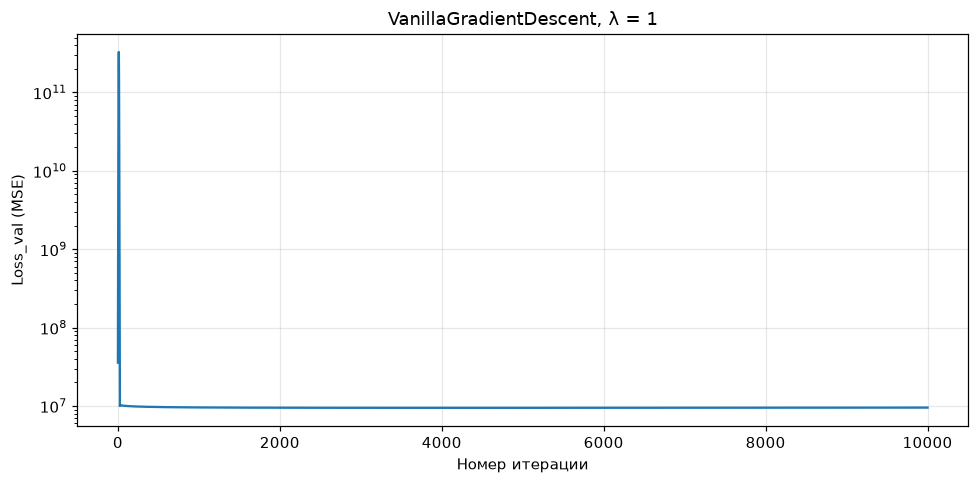

In [8]:
show_result('VanillaGradientDescent')


#### 6. Исследование StochasticGradientDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите StochasticGradientDescent с шагом lyamda на train, вычислите R_train ^ 2 и Loss_train;

протестируйте StochasticGradientDescent с шагом lyamda на val, вычислите Loss_val.

2. Найдите лучший шаг lyamda по минимальному Loss_val.

In [9]:
class StochasticGradientDescent(BaseDescent):
    def __init__(self, lyamda=0.1, batch_size=32, **kwargs):
        super().__init__(lyamda=lyamda, **kwargs)
        self.batch_size = batch_size

    def update(self, X, y, k):
        indices = self.rng.choice(len(y), size=min(self.batch_size, len(y)), replace=False)
        X_batch, y_batch = X[indices], y[indices]
        gradient = 2 * X_batch.T @ (X_batch @ self.w - y_batch) / len(indices)
        return -self.lr(k) * gradient


search_step(StochasticGradientDescent)


,λ,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,0.000010,"63,389,325.552462",0.007296,"35,408,739.824938",10000,Лимит итераций
1,0.000100,"59,428,328.447870",0.069327,"32,482,433.884919",10000,Лимит итераций
2,0.001000,"35,861,882.778147",0.438387,"15,923,678.747357",10000,Лимит итераций
3,0.010000,"20,168,089.753621",0.684159,"9,832,626.973329",10000,Лимит итераций
4,0.100000,"17,505,872.582341",0.725850,"9,902,178.151761",10000,Лимит итераций
5,1.000000,"49,629,865.333800",0.222775,"50,217,066.901382",10000,Лимит итераций


Лучший шаг: 0.01
Минимальный Loss_val: 9,832,626.97


#### 7. Тестирование StochasticGradientDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [10]:
evaluate_test('StochasticGradientDescent')


,Loss_test,R²_test
StochasticGradientDescent,"29,912,456.082053",0.544646


#### 8. Вывод по StochasticGradientDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

,Метод,Лучшее λ,Loss_train,Loss_test,R²_train,Число итераций
0,StochasticGradientDescent,0.010000,"20,168,089.753621","29,912,456.082053",0.684159,10000


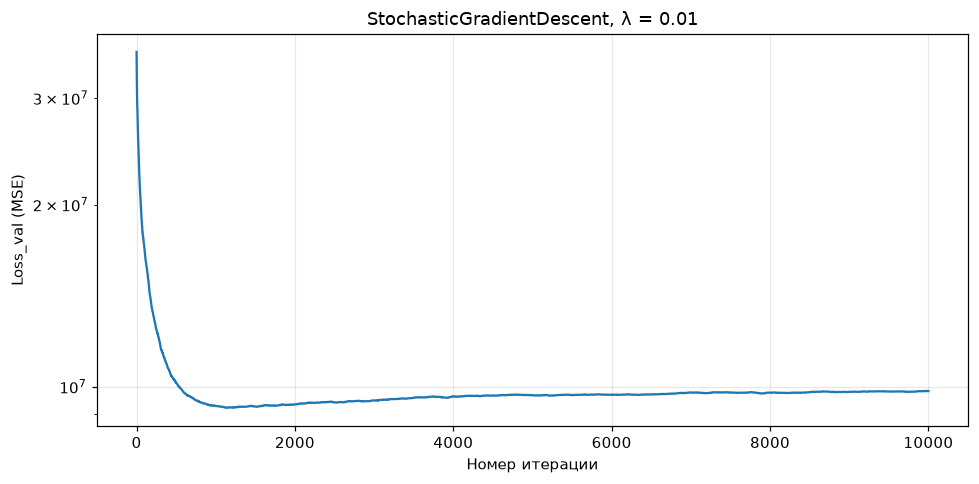

In [11]:
show_result('StochasticGradientDescent')


#### 9. Исследование SAGDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите SAGDescent с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте SAGDescent с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [12]:
class SAGDescent(BaseDescent):
    def initialize(self, X):
        super().initialize(X)
        self.gradient_memory = np.zeros_like(X)
        self.average_gradient = np.zeros(X.shape[1])

    def update(self, X, y, k):
        j = self.rng.integers(len(y))
        new_gradient = 2 * (X[j] @ self.w - y[j]) * X[j]
        self.average_gradient += (new_gradient - self.gradient_memory[j]) / len(y)
        self.gradient_memory[j] = new_gradient
        return -self.lr(k) * self.average_gradient


search_step(SAGDescent)


,λ,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,0.000010,"63,492,026.493789",0.005687,"35,484,255.424113",10000,Лимит итераций
1,0.000100,"60,355,047.860093",0.054814,"33,158,386.481241",10000,Лимит итераций
2,0.001000,"39,139,600.100665",0.387057,"18,041,714.360350",10000,Лимит итераций
3,0.010000,"20,402,097.702966",0.680494,"10,008,413.573110",10000,Лимит итераций
4,0.100000,"17,803,770.613458",0.721185,"10,150,312.263291",10000,Лимит итераций
5,1.000000,"14,613,843.281775",0.771141,"9,037,132.983542",10000,Лимит итераций


Лучший шаг: 1
Минимальный Loss_val: 9,037,132.98


#### 10. Тестирование SAGDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [13]:
evaluate_test('SAGDescent')


,Loss_test,R²_test
SAGDescent,"25,223,014.783015",0.616033


#### 11. Вывод по SAGDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

,Метод,Лучшее λ,Loss_train,Loss_test,R²_train,Число итераций
0,SAGDescent,1.000000,"14,613,843.281775","25,223,014.783015",0.771141,10000


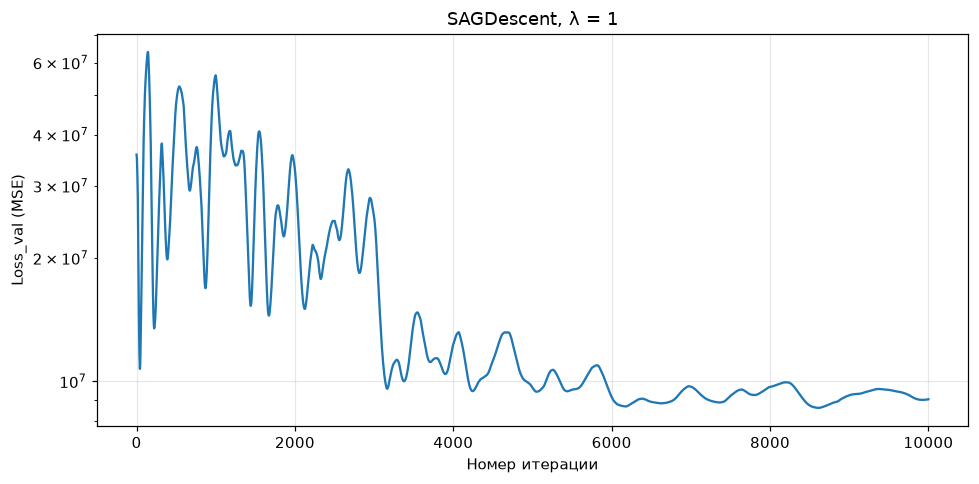

In [14]:
show_result('SAGDescent')


#### 12. Исследование MomentumDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите MomentumDescent с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте MomentumDescent с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [15]:
class MomentumDescent(BaseDescent):
    def __init__(self, lyamda=0.1, alpha=0.9, **kwargs):
        super().__init__(lyamda=lyamda, **kwargs)
        self.alpha = alpha

    def initialize(self, X):
        super().initialize(X)
        self.h = np.zeros(X.shape[1])

    def update(self, X, y, k):
        self.h = self.alpha * self.h + self.lr(k) * self.gradient
        return -self.h


search_step(MomentumDescent)


,λ,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,0.000010,"59,420,178.257660",0.069454,"32,475,203.435817",10000,Лимит итераций
1,0.000100,"35,815,658.320381",0.439111,"15,891,067.351778",10000,Лимит итераций
2,0.001000,"20,146,740.725230",0.684493,"9,915,196.989832",10000,Лимит итераций
3,0.010000,"17,498,831.640946",0.725961,"9,985,520.174664",10000,Лимит итераций
4,0.100000,"14,245,575.130029",0.776908,"9,529,713.072341",10000,Лимит итераций
5,1.000000,"13,050,312.485421",0.795626,"10,654,506.288939",10000,Лимит итераций


Лучший шаг: 0.1
Минимальный Loss_val: 9,529,713.07


#### 13. Тестирование MomentumDescent с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [16]:
evaluate_test('MomentumDescent')


,Loss_test,R²_test
MomentumDescent,"25,048,145.820693",0.618695


#### 14. Вывод по MomentumDescent

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

,Метод,Лучшее λ,Loss_train,Loss_test,R²_train,Число итераций
0,MomentumDescent,0.100000,"14,245,575.130029","25,048,145.820693",0.776908,10000


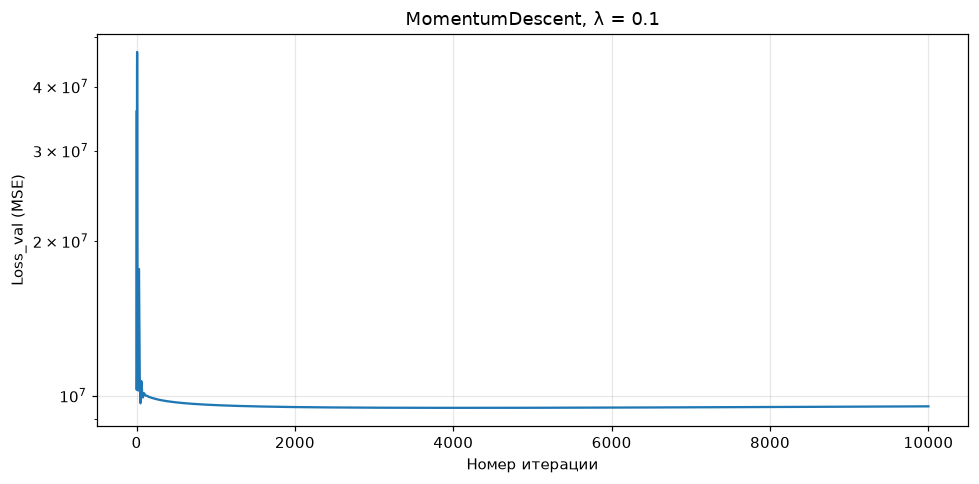

In [17]:
show_result('MomentumDescent')


#### 15. Исследование Adam

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучите Adam с шагом lyamda на train, вычисляем R^2_train и Loss_train;

протестируйте Adam с шагом lyamda на val, вычисляем Loss_val.

2. Найдите наилучший шаг lyamda по минимальному Loss_val.

In [18]:
class Adam(BaseDescent):
    def __init__(self, lyamda=0.1, beta1=0.9, beta2=0.999, eps=1e-8, **kwargs):
        super().__init__(lyamda=lyamda, **kwargs)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

    def initialize(self, X):
        super().initialize(X)
        self.m = np.zeros(X.shape[1])
        self.v = np.zeros(X.shape[1])

    def update(self, X, y, k):
        self.m = self.beta1 * self.m + (1 - self.beta1) * self.gradient
        self.v = self.beta2 * self.v + (1 - self.beta2) * self.gradient ** 2
        m_corrected = self.m / (1 - self.beta1 ** (k + 1))
        v_corrected = self.v / (1 - self.beta2 ** (k + 1))
        return -self.lr(k) * m_corrected / (np.sqrt(v_corrected) + self.eps)


search_step(Adam)


,λ,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,0.000010,"63,067,263.849885",0.012339,"35,144,785.928008",10000,Лимит итераций
1,0.000100,"56,397,476.638700",0.116791,"30,074,511.089653",10000,Лимит итераций
2,0.001000,"22,865,843.708878",0.641911,"8,862,302.871678",10000,Лимит итераций
3,0.010000,"12,998,452.226164",0.796439,"11,106,964.081017",10000,Лимит итераций
4,0.100000,"12,933,313.886539",0.797459,"11,799,886.530567",3134,Сходимость
5,1.000000,"12,933,313.040212",0.797459,"11,655,279.463689",2106,Сходимость


Лучший шаг: 0.001
Минимальный Loss_val: 8,862,302.87


#### 16. Тестирование Adam с лучшим шагом

Выведите (R_test)^2 и Loss_test.

In [19]:
evaluate_test('Adam')


,Loss_test,R²_test
Adam,"31,840,043.498704",0.515302


#### 17. Вывод по Adam

1. Выведите на экран: лучший шаг, loss_train (для лучшего шага), loss_test, r^2_train (для лучшего шага), число итераций на val;

2. Отобразите график зависимости Loss_val для лучшего шага от числа итераций.

,Метод,Лучшее λ,Loss_train,Loss_test,R²_train,Число итераций
0,Adam,0.001000,"22,865,843.708878","31,840,043.498704",0.641911,10000


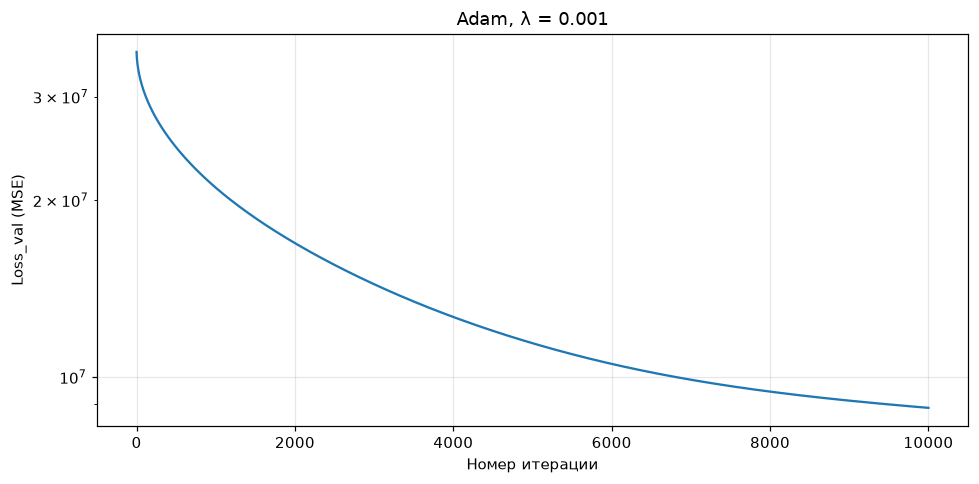

In [20]:
show_result('Adam')


#### 18. Постройте сравнительную таблицу методов

Таблица показана в лекции (таб. 2)

,Лучшее λ,Loss_train,Loss_test,R²_train,R²_test,Число итераций
Метод,,,,,,
VanillaGradientDescent,1.000000,"14,246,600.500729","25,049,576.326759",0.776892,0.618673,10000
StochasticGradientDescent,0.010000,"20,168,089.753621","29,912,456.082053",0.684159,0.544646,10000
SAGDescent,1.000000,"14,613,843.281775","25,223,014.783015",0.771141,0.616033,10000
MomentumDescent,0.100000,"14,245,575.130029","25,048,145.820693",0.776908,0.618695,10000
Adam,0.001000,"22,865,843.708878","31,840,043.498704",0.641911,0.515302,10000


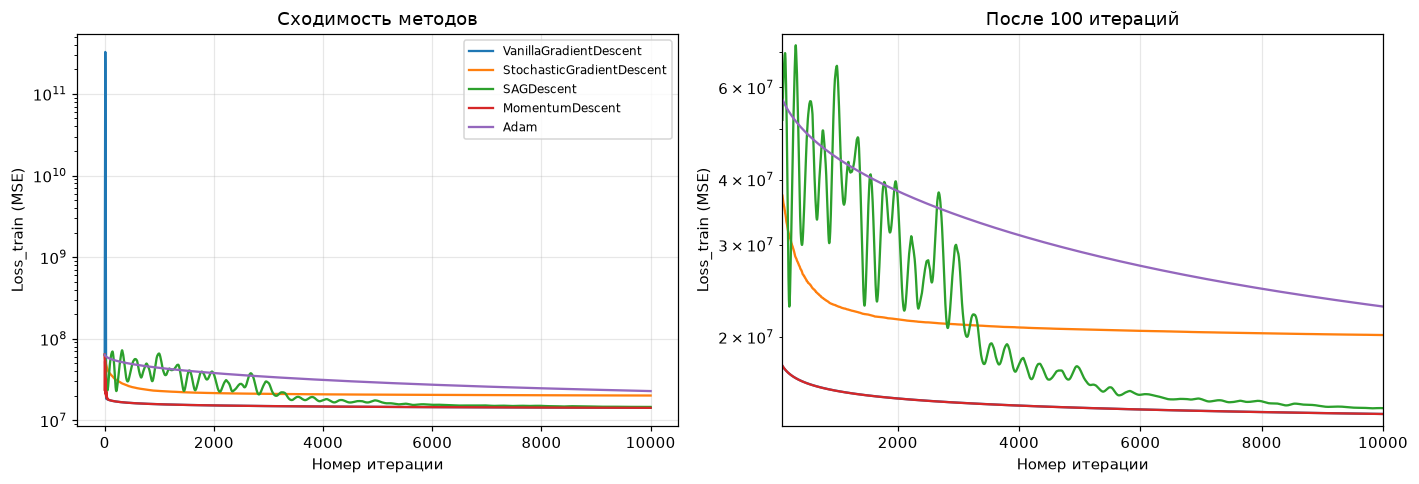

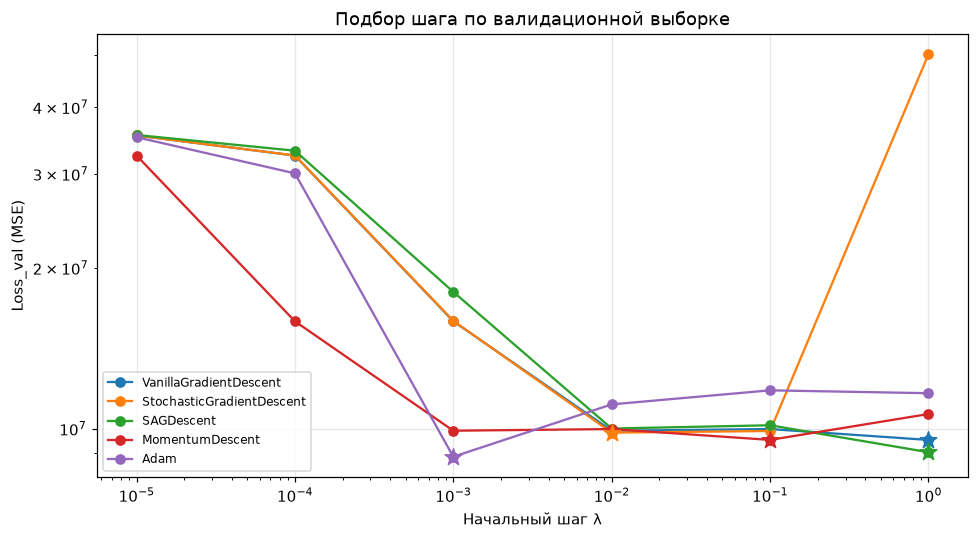

In [21]:
comparison_rows = []
for name, model in best_models.items():
    row = search_results[name].loc[search_results[name]['λ'].eq(model.lyamda)].iloc[0]
    comparison_rows.append({
        'Метод': name,
        'Лучшее λ': model.lyamda,
        'Loss_train': row['Loss_train'],
        'Loss_test': test_results[name]['Loss_test'],
        'R²_train': row['R²_train'],
        'R²_test': test_results[name]['R²_test'],
        'Число итераций': model.n_iter
    })

comparison = pd.DataFrame(comparison_rows).set_index('Метод')
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, model in best_models.items():
    for ax in axes:
        ax.plot(np.arange(len(model.train_history)), model.train_history, label=name)

for ax in axes:
    ax.set(xlabel='Номер итерации', ylabel='Loss_train (MSE)')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
axes[0].set_title('Сходимость методов')
axes[1].set_title('После 100 итераций')
axes[1].set_xlim(100, max(model.n_iter for model in best_models.values()))
tail_losses = np.concatenate([model.train_history[100:] for model in best_models.values()])
axes[1].set_ylim(tail_losses.min() * 0.95, tail_losses.max() * 1.05)
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for name, table in search_results.items():
    finite = np.isfinite(table['Loss_val'])
    ax.plot(table.loc[finite, 'λ'], table.loc[finite, 'Loss_val'], marker='o', label=name)
    best = table.loc[table['Loss_val'].idxmin()]
    ax.scatter(best['λ'], best['Loss_val'], marker='*', s=130, zorder=5)
ax.set(xscale='log', yscale='log', xlabel='Начальный шаг λ',
       ylabel='Loss_val (MSE)', title='Подбор шага по валидационной выборке')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


#### 19. Сделайте вывод о том, какой метод и какой шаг в итоге самые оптимальные, обратите внимание на R^2, подумайте на что он влияет.

In [22]:
validation_losses = {
    name: search_results[name]['Loss_val'].min()
    for name in best_models
}
best_validation_name = min(validation_losses, key=validation_losses.get)
best_test_name = comparison['Loss_test'].idxmin()
best_row = comparison.loc[best_test_name]
baseline_prediction = np.full_like(y_test, y_train.mean())
baseline_loss = mean_squared_error(y_test, baseline_prediction)
baseline_r2 = r2_score(y_test, baseline_prediction)

speed_rows = []
initial_loss = next(iter(best_models.values())).train_history[0]
lowest_train_loss = comparison['Loss_train'].min()
threshold = lowest_train_loss + 0.1 * (initial_loss - lowest_train_loss)
for name, model in best_models.items():
    reached = np.flatnonzero(np.asarray(model.train_history) <= threshold)
    speed_rows.append({
        'Метод': name,
        'Итерация достижения порога': int(reached[0]) if len(reached) else np.nan,
        'Остановка': model.status
    })
speed = pd.DataFrame(speed_rows).set_index('Метод')
print(f'Порог Loss_train: {threshold:,.2f}')
display(speed.style.format({'Итерация достижения порога': '{:.0f}'}, na_rep='Не достигнут'))
fastest_name = speed['Итерация достижения порога'].idxmin()
fastest_iteration = int(speed.loc[fastest_name, 'Итерация достижения порога'])

display(Markdown(f"""
Шаг для каждого метода подбирал по минимальному Loss_val, а затем проверял модель на test. На val лучший результат получился у {best_validation_name} с λ = {best_models[best_validation_name].lyamda:g}. На test первым оказался {best_test_name} с λ = {best_row['Лучшее λ']:g}: MSE = {best_row['Loss_test']:,.2f}, R² = {best_row['R²_test']:.4f}. RMSE получился {np.sqrt(best_row['Loss_test']):,.2f} в единицах цены. Результаты на val и test различаются, что вполне возможно при выборках всего по 100 автомобилей.

По итогам этого сравнения я бы выбрал MomentumDescent с λ = 0.1. У Vanilla GD с λ = 1 тестовая ошибка почти такая же: разница всего {100 * abs(comparison.loc['VanillaGradientDescent', 'Loss_test'] - comparison.loc['MomentumDescent', 'Loss_test']) / comparison.loc['MomentumDescent', 'Loss_test']:.4f}%. По такой разнице нельзя уверенно сказать, что один метод лучше другого. Но на графике у Vanilla GD в начале виден большой скачок ошибки. У Momentum такого скачка нет, а итоговое качество практически совпадает.

R² показывает, насколько модель лучше постоянного прогноза средним значением цены на той же выборке. Он считается как 1 − SSE / SST, где SSE — сумма квадратов ошибок, а SST — сумма квадратов отклонений цен от среднего. При R² = 1 все прогнозы точные, при 0 результат соответствует прогнозу средним, а при отрицательном значении он хуже. В данном случае модель объясняет примерно {best_row['R²_test'] * 100:.2f}% разброса цен на test. Это не процент точно угаданных цен. Сам R² не участвует в обновлении весов: обучение идёт по MSE. На одной выборке меньшему MSE соответствует больший R².

Для проверки сравнил результат с простым прогнозом средней ценой из train. Он даёт на test MSE = {baseline_loss:,.2f} и R² = {baseline_r2:.4f}, то есть модель заметно лучше. При этом у лучшего по test метода R² на train равен {best_row['R²_train']:.4f}, а на test — {best_row['R²_test']:.4f}. На новых данных качество ниже, поэтому смотреть только на результат обучения было бы неправильно.

Все выбранные модели дошли до лимита 10000 итераций. Чтобы сравнить скорость, в таблице выше посмотрел, когда ошибка снизилась на 90% от начальной до наименьшей итоговой Loss_train среди этих моделей. Первым этого уровня достиг {fastest_name}, на итерации {fastest_iteration}. Это только общий ориентир: он не означает, что метод уже сошёлся.

По числу итераций нельзя напрямую сравнивать время работы. Vanilla GD, Momentum и Adam за одно обновление используют все 800 объектов, SGD — 32, а SAG — один объект и сохранённые градиенты. В моём коде после каждого шага дополнительно считаются полные ошибки и градиент для проверки остановки. Поэтому вывод о скорости здесь относится к графикам и числу обновлений. На другом разбиении или при другом лимите обучения результаты могут измениться.
"""))


Порог Loss_train: 19,206,537.55


,Итерация достижения порога,Остановка
Метод,,
VanillaGradientDescent,24,Лимит итераций
StochasticGradientDescent,Не достигнут,Лимит итераций
SAGDescent,3355,Лимит итераций
MomentumDescent,36,Лимит итераций
Adam,Не достигнут,Лимит итераций



Шаг для каждого метода подбирал по минимальному Loss_val, а затем проверял модель на test. На val лучший результат получился у Adam с λ = 0.001. На test первым оказался MomentumDescent с λ = 0.1: MSE = 25,048,145.82, R² = 0.6187. RMSE получился 5,004.81 в единицах цены. Результаты на val и test различаются, что вполне возможно при выборках всего по 100 автомобилей.

По итогам этого сравнения я бы выбрал MomentumDescent с λ = 0.1. У Vanilla GD с λ = 1 тестовая ошибка почти такая же: разница всего 0.0057%. По такой разнице нельзя уверенно сказать, что один метод лучше другого. Но на графике у Vanilla GD в начале виден большой скачок ошибки. У Momentum такого скачка нет, а итоговое качество практически совпадает.

R² показывает, насколько модель лучше постоянного прогноза средним значением цены на той же выборке. Он считается как 1 − SSE / SST, где SSE — сумма квадратов ошибок, а SST — сумма квадратов отклонений цен от среднего. При R² = 1 все прогнозы точные, при 0 результат соответствует прогнозу средним, а при отрицательном значении он хуже. В данном случае модель объясняет примерно 61.87% разброса цен на test. Это не процент точно угаданных цен. Сам R² не участвует в обновлении весов: обучение идёт по MSE. На одной выборке меньшему MSE соответствует больший R².

Для проверки сравнил результат с простым прогнозом средней ценой из train. Он даёт на test MSE = 66,002,014.09 и R² = -0.0047, то есть модель заметно лучше. При этом у лучшего по test метода R² на train равен 0.7769, а на test — 0.6187. На новых данных качество ниже, поэтому смотреть только на результат обучения было бы неправильно.

Все выбранные модели дошли до лимита 10000 итераций. Чтобы сравнить скорость, в таблице выше посмотрел, когда ошибка снизилась на 90% от начальной до наименьшей итоговой Loss_train среди этих моделей. Первым этого уровня достиг VanillaGradientDescent, на итерации 24. Это только общий ориентир: он не означает, что метод уже сошёлся.

По числу итераций нельзя напрямую сравнивать время работы. Vanilla GD, Momentum и Adam за одно обновление используют все 800 объектов, SGD — 32, а SAG — один объект и сохранённые градиенты. В моём коде после каждого шага дополнительно считаются полные ошибки и градиент для проверки остановки. Поэтому вывод о скорости здесь относится к графикам и числу обновлений. На другом разбиении или при другом лимите обучения результаты могут измениться.
